# Smart Expense & Savings Predictor: Bank Transaction Analytics
## 1. Project Setup & Environment
## 2. Data Loading & Cleaning
## 3. Categorization & Rule-Based Keyword Tagging
## 4. Exploratory Data Analysis (EDA) & Visualizations
## 5. Time-Series Feature Engineering
## 6. Machine Learning Model for Expense & Savings Prediction
## 7. Automated Financial Advisory & Recommendation Rules

In [2]:
# Cell 1: Import core packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setting visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Cell 2: Load bank.xlsx and clean data types
df = pd.read_excel('bank.xlsx', sheet_name='Sheet1')

# 1. Clean account number and drop redundant dot column
df['Account No'] = df['Account No'].astype(str).str.replace("'", "")
if '.' in df.columns:
    df.drop(columns=['.'], inplace=True)

# 2. Convert date columns
df['DATE'] = pd.to_datetime(df['DATE'])
df['VALUE DATE'] = pd.to_datetime(df['VALUE DATE'])

# 3. Fill NaN withdrawal and deposit values with 0
df['WITHDRAWAL AMT'] = df['WITHDRAWAL AMT'].fillna(0)
df['DEPOSIT AMT'] = df['DEPOSIT AMT'].fillna(0)
df['TRANSACTION DETAILS'] = df['TRANSACTION DETAILS'].fillna('UNKNOWN').astype(str)

# 4. Extract datetime features
df['Year'] = df['DATE'].dt.year
df['Month'] = df['DATE'].dt.month
df['YearMonth'] = df['DATE'].dt.to_period('M')

print(f"Total Transactions Processed: {len(df):,}")
df[['DATE', 'TRANSACTION DETAILS', 'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT']].head()

Total Transactions Processed: 116,201


,DATE,TRANSACTION DETAILS,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT
0,2017-06-29,TRF FROM Indiaforensic SERVICES,0.0,1000000.0,1000000.0
1,2017-07-05,TRF FROM Indiaforensic SERVICES,0.0,1000000.0,2000000.0
2,2017-07-18,FDRL/INTERNAL FUND TRANSFE,0.0,500000.0,2500000.0
3,2017-08-01,TRF FRM Indiaforensic SERVICES,0.0,3000000.0,5500000.0
4,2017-08-16,FDRL/INTERNAL FUND TRANSFE,0.0,500000.0,6000000.0


In [4]:
# Cell 3: Rule-based category tagging
def categorize_transaction(text):
    text = text.upper()
    if any(k in text for k in ['TRF', 'TRANSFER', 'INTERNAL', 'SWIFT', 'NEFT', 'RTGS']):
        return 'Fund Transfers'
    elif any(k in text for k in ['ATM', 'CASH', 'CWDR', 'WDR']):
        return 'Cash Withdrawal'
    elif any(k in text for k in ['CHQ', 'CHEQUE', 'CLEARING']):
        return 'Cheque Clearing'
    elif any(k in text for k in ['INT', 'INTEREST', 'COMM', 'CHARGE', 'TAX', 'FEE']):
        return 'Bank Charges & Interest'
    elif any(k in text for k in ['POS', 'RETAIL', 'STORE', 'SHOP', 'CARD']):
        return 'POS & Retail'
    else:
        return 'Other Operations'

df['Category'] = df['TRANSACTION DETAILS'].apply(categorize_transaction)
df['Category'].value_counts()

,count
Category,
Other Operations,52281
Fund Transfers,36675
Cash Withdrawal,19103
Bank Charges & Interest,3132
Cheque Clearing,2605
POS & Retail,2405


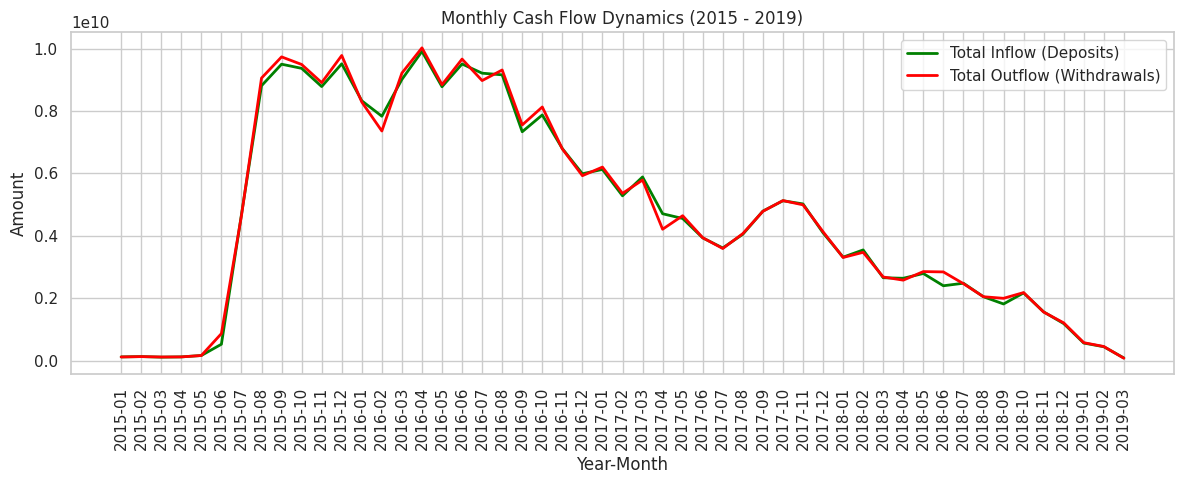

In [5]:
# Cell 4: Monthly Cash Flow Aggregation
monthly_summary = df.groupby('YearMonth').agg(
    Total_Withdrawals=('WITHDRAWAL AMT', 'sum'),
    Total_Deposits=('DEPOSIT AMT', 'sum'),
    Avg_Balance=('BALANCE AMT', 'mean'),
    Tx_Count=('Account No', 'count')
).reset_index()

monthly_summary['YearMonth_Str'] = monthly_summary['YearMonth'].astype(str)
monthly_summary['Net_Savings'] = monthly_summary['Total_Deposits'] - monthly_summary['Total_Withdrawals']

# Visualization: Monthly Inflow vs Outflow
plt.figure(figsize=(12, 5))
plt.plot(monthly_summary['YearMonth_Str'], monthly_summary['Total_Deposits'], label='Total Inflow (Deposits)', color='green', linewidth=2)
plt.plot(monthly_summary['YearMonth_Str'], monthly_summary['Total_Withdrawals'], label='Total Outflow (Withdrawals)', color='red', linewidth=2)
plt.xticks(rotation=90)
plt.title('Monthly Cash Flow Dynamics (2015 - 2019)')
plt.xlabel('Year-Month')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Cell 5: Feature Engineering for Time Series Forecasting
df_ml = monthly_summary.copy()

# Create target: Next Month's Outflow (Expenses)
df_ml['Target_Next_Month_Expenses'] = df_ml['Total_Withdrawals'].shift(-1)

# Create Lag Features
df_ml['Expense_Lag1'] = df_ml['Total_Withdrawals'].shift(1)
df_ml['Expense_Lag2'] = df_ml['Total_Withdrawals'].shift(2)
df_ml['Inflow_Lag1'] = df_ml['Total_Deposits'].shift(1)

# Rolling Averages
df_ml['Expense_Rolling3'] = df_ml['Total_Withdrawals'].rolling(window=3).mean()
df_ml['Expense_Rolling6'] = df_ml['Total_Withdrawals'].rolling(window=6).mean()

# Drop rows with NaN due to lagging
df_ml_clean = df_ml.dropna().copy()
print(f"Features ready. Cleaned sample count: {len(df_ml_clean)}")

Features ready. Cleaned sample count: 45


In [7]:
# Cell 6: Train Random Forest Regressor
features = ['Total_Withdrawals', 'Total_Deposits', 'Expense_Lag1', 'Expense_Lag2', 'Inflow_Lag1', 'Expense_Rolling3', 'Expense_Rolling6']
X = df_ml_clean[features]
y = df_ml_clean['Target_Next_Month_Expenses']

# Split data sequentially (preserving chronological order)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.3f}")

Model Evaluation Metrics:
Mean Absolute Error (MAE): 1,935,718,732.20
Root Mean Squared Error (RMSE): 2,384,521,386.32
R² Score: -7.643


In [8]:
# Cell 7: Automated Advisory Engine
latest_month = monthly_summary.iloc[-1]
predicted_exp = y_pred[-1]
expected_inflow = latest_month['Total_Deposits']
projected_savings = expected_inflow - predicted_exp

print("=== AUTOMATED PERSONAL FINANCE REPORT ===")
print(f"Latest Recorded Monthly Inflow:  {expected_inflow:,.2f}")
print(f"Projected Outflow (Next Month): {predicted_exp:,.2f}")
print(f"Projected Net Savings:           {projected_savings:,.2f}")

savings_rate = (projected_savings / expected_inflow) * 100 if expected_inflow > 0 else 0
print(f"Projected Savings Rate:          {savings_rate:.2f}%")

if savings_rate < 20:
    print("⚠️ ALERT: Projected savings rate is below recommended 20% benchmark. Review high-frequency withdrawals.")
else:
    print("✅ HEALTHY: Projected cash flow meets healthy liquidity targets.")

=== AUTOMATED PERSONAL FINANCE REPORT ===
Latest Recorded Monthly Inflow:  82,334,352.50
Projected Outflow (Next Month): 4,455,626,913.95
Projected Net Savings:           -4,373,292,561.45
Projected Savings Rate:          -5311.63%
⚠️ ALERT: Projected savings rate is below recommended 20% benchmark. Review high-frequency withdrawals.
